<a href="https://colab.research.google.com/github/AKutergin/dsp-seminars/blob/kutergin_lab4/seminars/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


/tmp/ipykernel_3867/3758247855.py:15: RuntimeWarning: divide by zero encountered in divide
  f_inv_sqrt = np.where(freqs == 0, 0, 1 / np.sqrt(freqs))


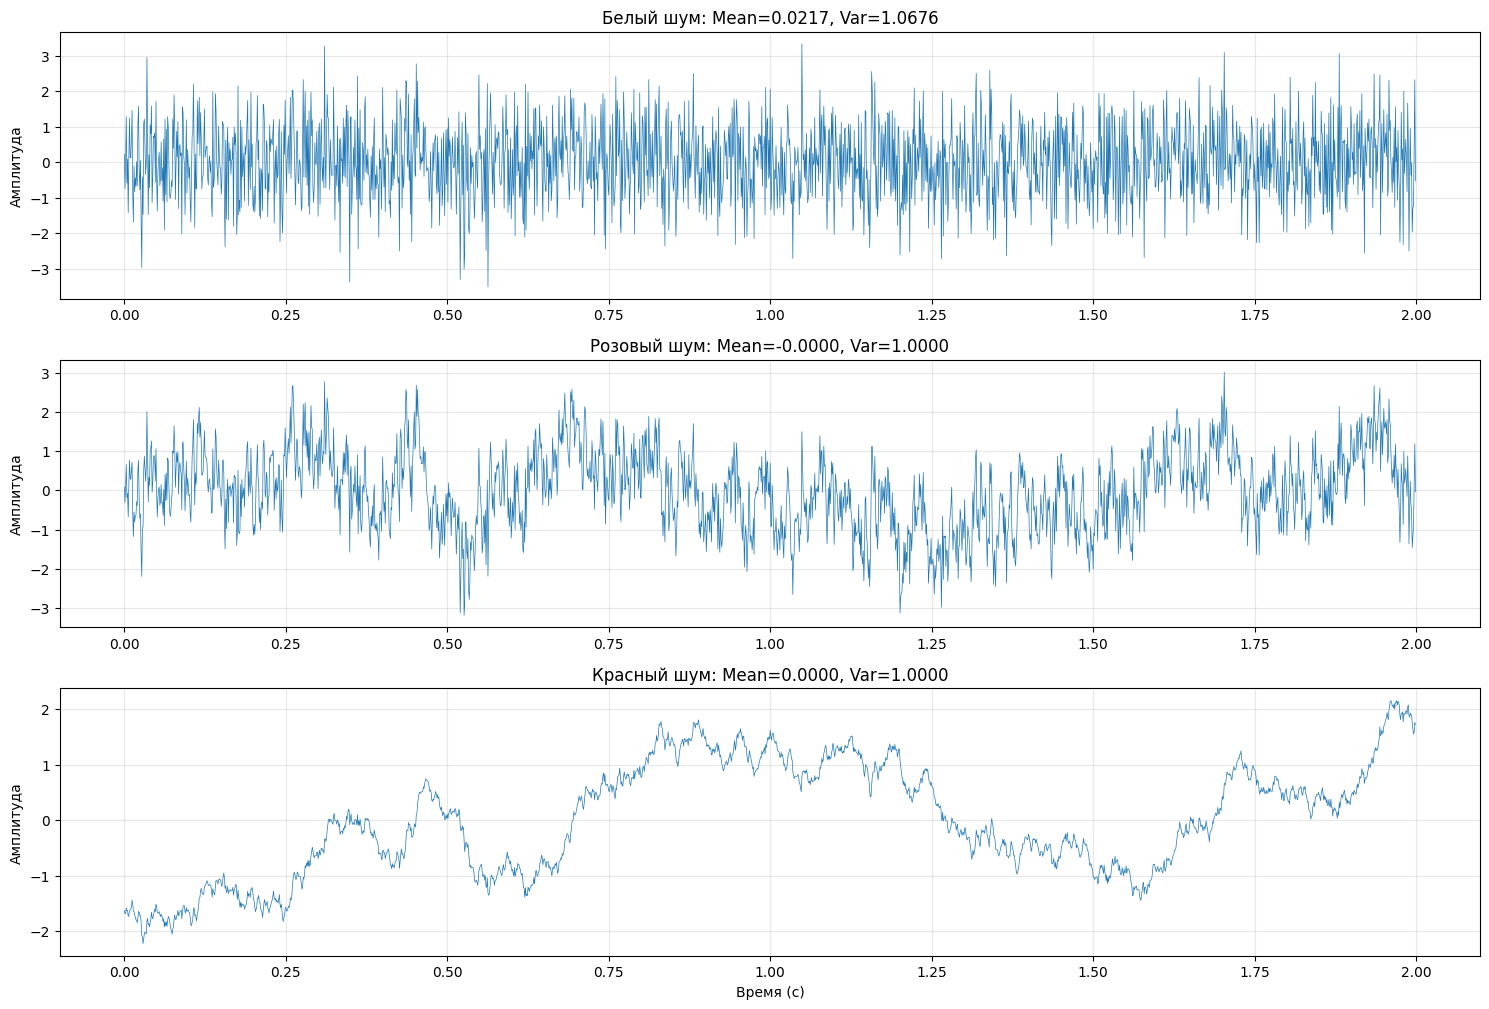

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
fs = 1000
duration = 2
N = fs * duration
t = np.arange(N) / fs

white_noise = np.random.normal(0, 1, N)

white_fft = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(N, 1/fs)

f_inv_sqrt = np.where(freqs == 0, 0, 1 / np.sqrt(freqs))
pink_fft = white_fft * f_inv_sqrt
pink_noise = np.fft.irfft(pink_fft, n=N)
pink_noise = (pink_noise - np.mean(pink_noise)) / np.std(pink_noise)

red_noise = np.cumsum(white_noise)
red_noise = (red_noise - np.mean(red_noise)) / np.std(red_noise) # Нормализация

plt.figure(figsize=(15, 10))

noises = [(white_noise, 'Белый шум'), (pink_noise, 'Розовый шум'), (red_noise, 'Красный шум')]

for i, (noise, label) in enumerate(noises):
    plt.subplot(3, 1, i+1)
    plt.plot(t, noise, lw=0.5)
    plt.title(f'{label}: Mean={np.mean(noise):.4f}, Var={np.var(noise):.4f}')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Амплитуда')

plt.tight_layout()
plt.xlabel('Время (с)')
plt.show()

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Визуально шумы отличаются, белый более хаотичный в сравнении с розовым и красным. Для белого шума теоретические параметры были заданы как $Mean = 0$ и $Var = 1$, вычисленные значения $Mean \approx 0.0217$, $Var \approx 1.0676$ очень близки к ним.Для розового и красного шумов среднее и дисперсия  результата получились идеальными

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


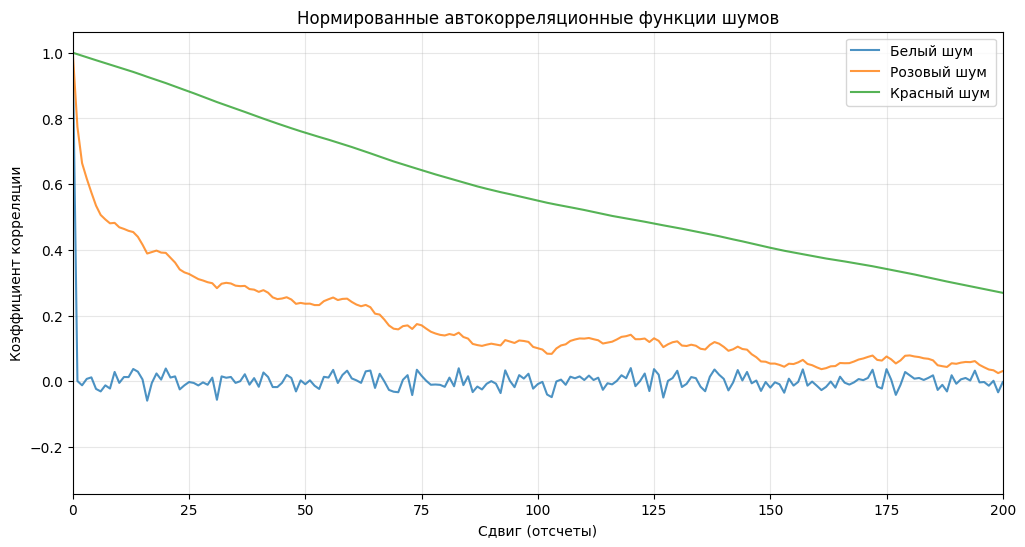

In [2]:
def get_normalized_acf(signal_data):
    # Вычисляем полную корреляцию сигнала с самим собой
    acf = np.correlate(signal_data, signal_data, mode='full')
    # Берем вторую половину (от нулевого сдвига до конца)
    acf = acf[len(acf)//2:]
    # Нормируем на максимальное значение (при нулевом сдвиге)
    return acf / acf[0]

# Вычисляем АКФ для каждого шума
acf_white = get_normalized_acf(white_noise)
acf_pink = get_normalized_acf(pink_noise)
acf_red = get_normalized_acf(red_noise)

# Создаем массив сдвигов в секундах или отсчетах
lags = np.arange(len(acf_white))

plt.figure(figsize=(12, 6))
plt.plot(lags, acf_white, label='Белый шум', alpha=0.8)
plt.plot(lags, acf_pink, label='Розовый шум', alpha=0.8)
plt.plot(lags, acf_red, label='Красный шум', alpha=0.8)

plt.title('Нормированные автокорреляционные функции шумов')
plt.xlabel('Сдвиг (отсчеты)')
plt.ylabel('Коэффициент корреляции')
plt.xlim(0, 200)  # Ограничим масштаб для наглядности
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


форма АКФ напрямую отражает степень внутренней связности и гладкости сигнала

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


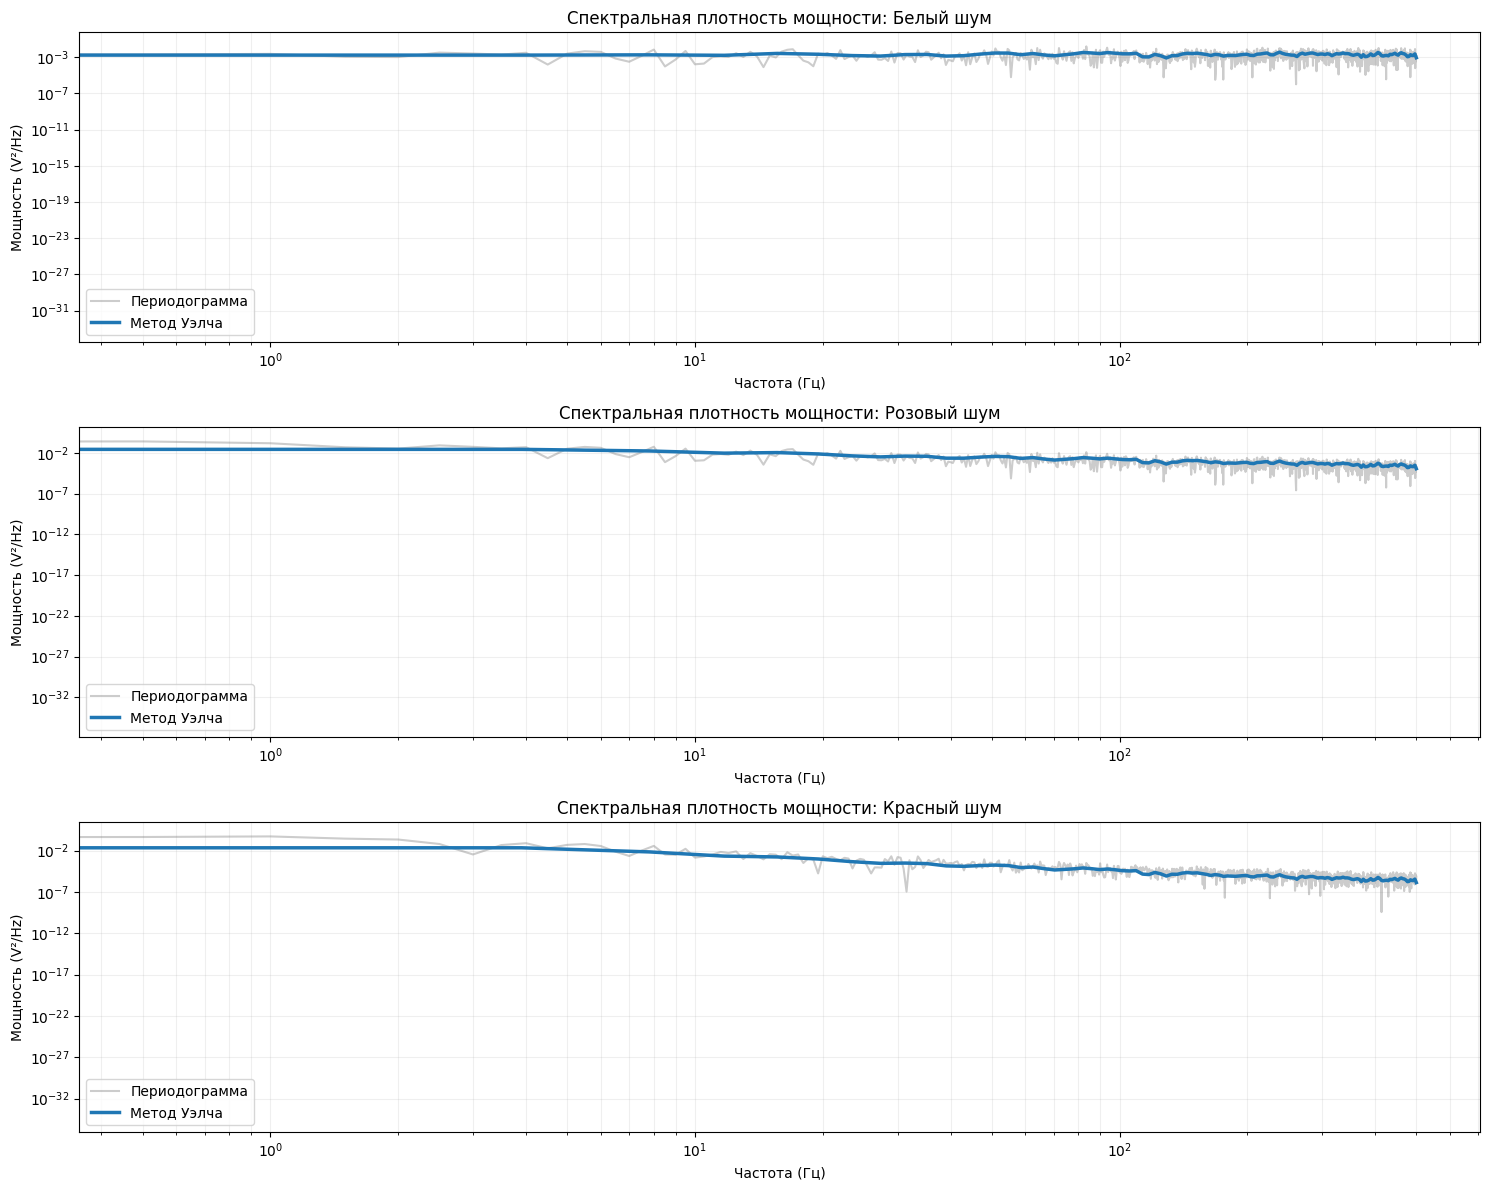

In [3]:
from scipy import signal

noises_list = [
    (white_noise, 'Белый шум'),
    (pink_noise, 'Розовый шум'),
    (red_noise, 'Красный шум')
]

plt.figure(figsize=(15, 12))

for i, (noise, label) in enumerate(noises_list):
    plt.subplot(3, 1, i+1)

    # 1. Периодограмма
    f_p, pxx_p = signal.periodogram(noise, fs)

    # 2. Метод Уэлча
    f_w, pxx_w = signal.welch(noise, fs, nperseg=256, noverlap=128, window='hann')

    # Построение в логарифмическом масштабе
    plt.loglog(f_p, pxx_p, alpha=0.4, label='Периодограмма', color='gray')
    plt.loglog(f_w, pxx_w, lw=2.5, label='Метод Уэлча')

    plt.title(f'Спектральная плотность мощности: {label}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Мощность (V²/Hz)')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


В двойном логарифмическом масштабе СПМ шумов представляют собой прямые линии. Наклон этой линии является «паспортом» шума: у белого он нулевой (равномерный спектр), у розового — умеренный (баланс частот), у красного — крутой (доминирование басов). Метод Уэлча позволяет экспериментально подтвердить эти теоретические наклоны, значительно снижая уровень визуального шума на графике.

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


In [ ]:
# Ваш код здесь

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


{Введите ваш ответ здесь}

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

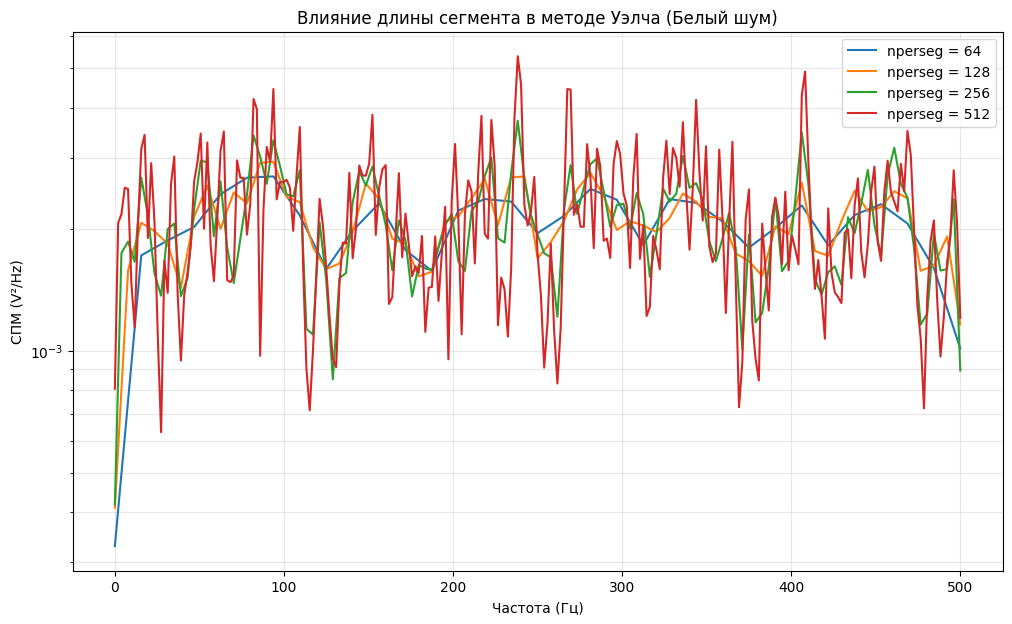

In [4]:
npersegs = [64, 128, 256, 512]
plt.figure(figsize=(12, 7))

for n in npersegs:
    f, pxx = signal.welch(white_noise, fs, nperseg=n, noverlap=n//2, window='hann')
    plt.semilogy(f, pxx, label=f'nperseg = {n}')

plt.title('Влияние длины сегмента в методе Уэлча (Белый шум)')
plt.xlabel('Частота (Гц)')
plt.ylabel('СПМ (V²/Hz)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


Изменение дисперсии в методе Уэлча напрямую зависит от количества усредняемых сегментов. Чем больше сегментов мы усредняем (меньше nperseg), тем ниже дисперсия (график глаже), но хуже частотное разрешение. И наоборот.

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


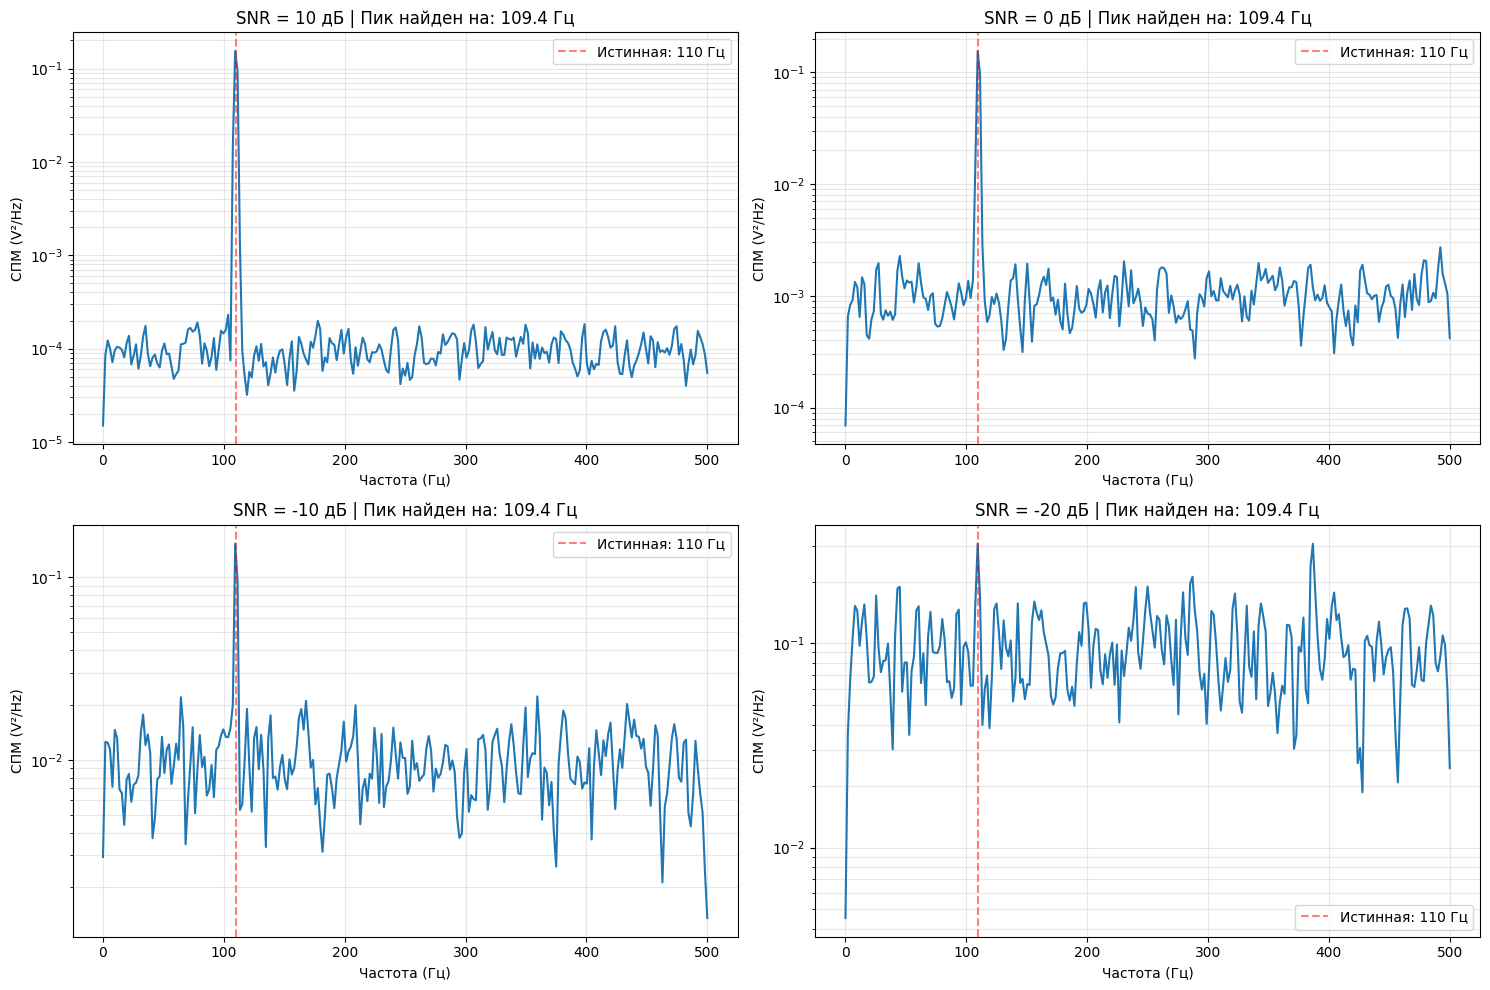

In [5]:
t = np.arange(0, duration, 1/fs)
f_true = 110
a_signal = 1
p_signal = (a_signal**2) / 2

snr_values = [10, 0, -10, -20]

plt.figure(figsize=(15, 10))

for i, snr in enumerate(snr_values):
    # Расчет дисперсии шума
    p_noise = p_signal * (10**(-snr/10))
    noise = np.random.normal(0, np.sqrt(p_noise), len(t))

    # Результирующий сигнал
    x = a_signal * np.sin(2 * np.pi * f_true * t) + noise

    # Оценка СПМ (nperseg=512 даст разрешение ~1.95 Гц)
    f, pxx = signal.welch(x, fs, nperseg=512, noverlap=256)

    # Поиск пика
    f_peak = f[np.argmax(pxx)]

    plt.subplot(2, 2, i+1)
    plt.semilogy(f, pxx)
    plt.axvline(f_true, color='r', linestyle='--', alpha=0.5, label=f'Истинная: {f_true} Гц')
    plt.title(f'SNR = {snr} дБ | Пик найден на: {f_peak:.1f} Гц')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('СПМ (V²/Hz)')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


отлично виден процесс «утопания» сигнала в шуме. До SNR = - 10 можжно уверенно обнаружить пик визуально.

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


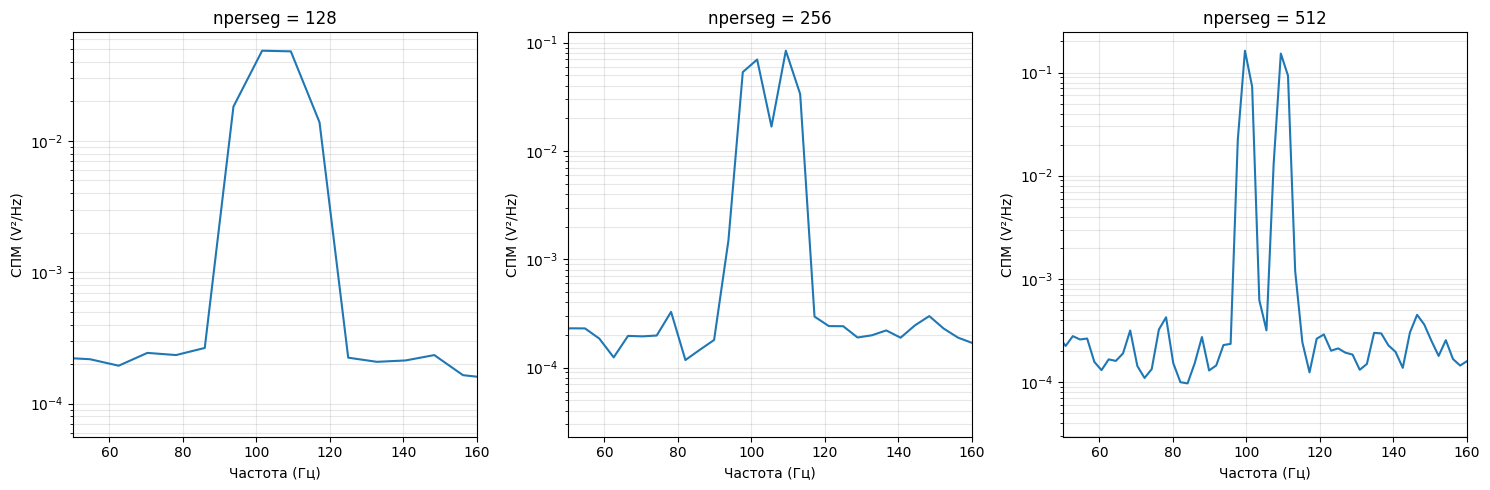

In [6]:
f1, f2 = 100, 110
x = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t) + np.random.normal(0, np.sqrt(0.1), len(t))

npersegs = [128, 256, 512]
plt.figure(figsize=(15, 5))

for i, n in enumerate(npersegs):
    f, pxx = signal.welch(x, fs, nperseg=n, noverlap=n//2)

    plt.subplot(1, 3, i+1)
    plt.semilogy(f, pxx)
    plt.title(f'nperseg = {n}')
    plt.xlim(50, 160) # Зуммируем область интереса
    plt.xlabel('Частота (Гц)')
    plt.ylabel('СПМ (V²/Hz)')
    plt.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


При длине сигмента 256, можно заметить небольшое разделение двух частот, а при 256 они уже четко разделены.    

*   $\Delta f \approx 1000 / 128 \approx 7.8$ Гц
*   $\Delta f \approx 1000 / 256 \approx 3.9$ Гц
*   $\Delta f \approx 1000 / 512 \approx 1.95$ Гц

